In [ ]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#Read the data file Customers.csv into dataframe, and inspect first few rows
df = pd.read_csv("../../data/raw/Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income,Spending Score,Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [5]:
df.shape

(2000, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   gender           2000 non-null   str  
 1   age              2000 non-null   int64
 2   annual_income    2000 non-null   int64
 3   spending_score   2000 non-null   int64
 4   profession       1965 non-null   str  
 5   work_experience  2000 non-null   int64
 6   family_size      2000 non-null   int64
dtypes: int64(5), str(2)
memory usage: 109.5 KB


In [ ]:
#Remove CustomerID from dataframe since no predictive power.  Renamed column names to snake case for easier reference in code
df = df.drop(columns=["CustomerID"]).rename(
    columns = {
        'Gender': 'gender',
        'Age': 'age',
        'Annual Income': 'annual_income',
        'Spending Score': 'spending_score',
        'Profession': 'profession',
        'Work Experience': 'work_experience',
        'Family Size': 'family_size',
    }
)

In [ ]:
#Check for null values: Only column with missing values is profession
df.isnull().sum()

gender              0
age                 0
annual_income       0
spending_score      0
profession         35
work_experience     0
family_size         0
dtype: int64

In [ ]:
#Check for duplicated rows: Looks good, no duplicate entries.
df.duplicated().sum()

np.int64(0)

In [ ]:
#Calculate the percentage of customers who are under age 15, given their limited spending power : about 14%
total = len(df)
under15_percent = (((df["age"] < 15).sum()) / total) * 100
under15_percent


np.float64(13.700000000000001)

In [ ]:
#Calculate the percentage of customers whoese work experience is greater than their age as this signals invalid records in the dataset: about 5%
((df["work_experience"] >= df["age"]).sum() / total) * 100


np.float64(5.2)

In [ ]:
#Calculate the percentage of customers where annual income is 0, shows low spending capacity: Not significant at all 0.1%
(((df["annual_income"] == 0).sum()) / total) * 100

np.float64(0.1)

In [ ]:
#Calculate the percentage of customers where work_experience is 0, likely to have low income and spending capacity: about 21%
(((df["work_experience"] == 0).sum()) / total) * 100

np.float64(21.55)


Summary for age
count    2000.000000
mean       48.960000
std        28.429747
min         0.000000
25%        25.000000
50%        48.000000
75%        73.000000
max        99.000000
Name: age, dtype: float64


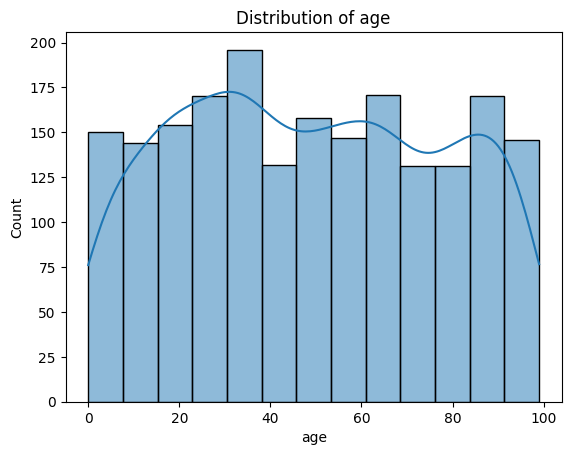

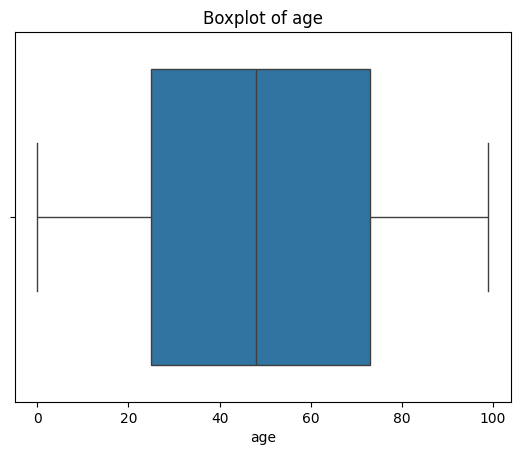


Summary for annual_income
count      2000.000000
mean     110731.821500
std       45739.536688
min           0.000000
25%       74572.000000
50%      110045.000000
75%      149092.750000
max      189974.000000
Name: annual_income, dtype: float64


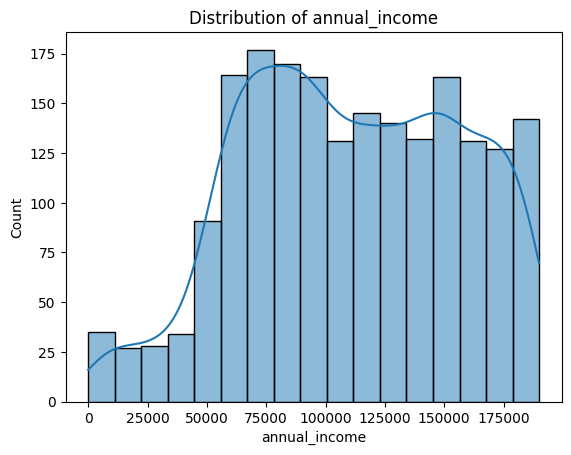

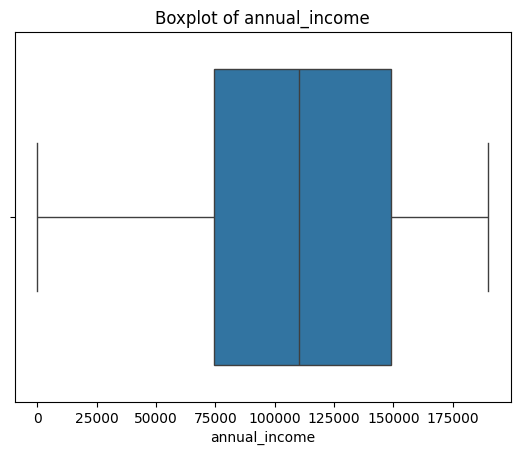


Summary for family_size
count    2000.000000
mean        3.768500
std         1.970749
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         9.000000
Name: family_size, dtype: float64


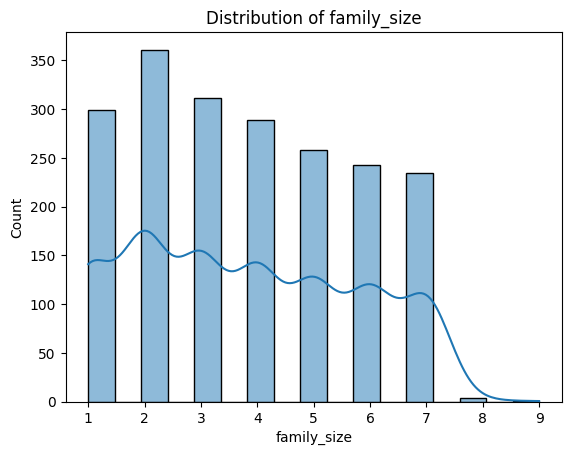

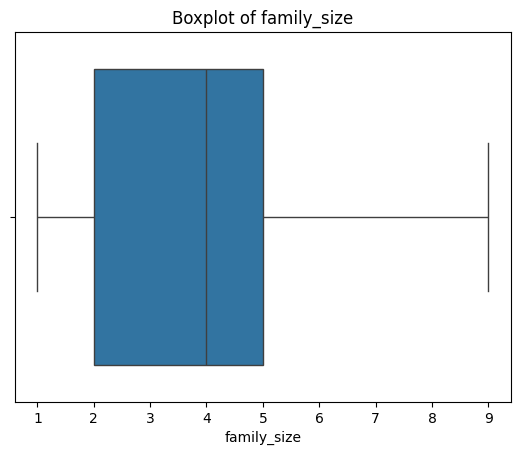


Summary for work_experience
count    2000.000000
mean        4.102500
std         3.922204
min         0.000000
25%         1.000000
50%         3.000000
75%         7.000000
max        17.000000
Name: work_experience, dtype: float64


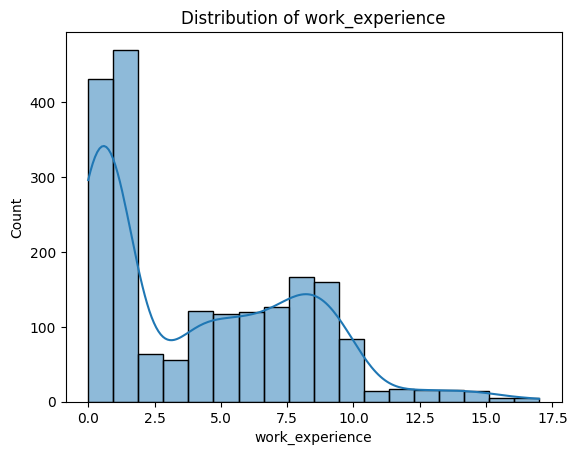

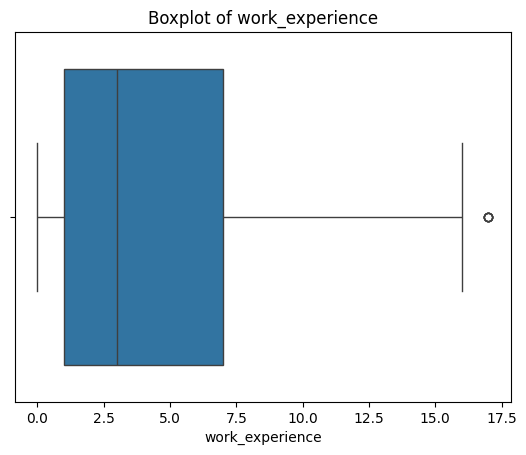


Summary for spending_score
count    2000.000000
mean       50.962500
std        27.934661
min         0.000000
25%        28.000000
50%        50.000000
75%        75.000000
max       100.000000
Name: spending_score, dtype: float64


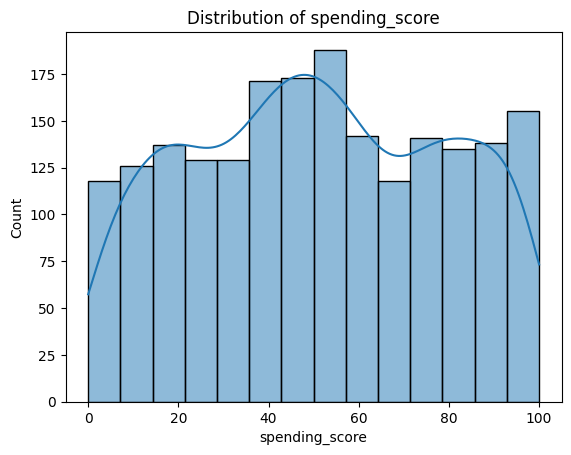

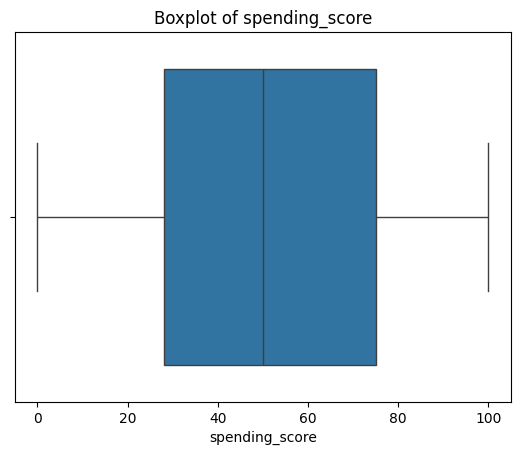

In [29]:
#Visualize distribution, median, quartiles and outliers for every numeric features
num_cols = ["age", "annual_income", "family_size", "work_experience", "spending_score"]

for col in num_cols:
    print(f"\nSummary for {col}")
    print(df[col].describe())
    
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [42]:
#Check for class imbalance in categorical features
cat_cols = ["gender", "profession"]

for col in cat_cols:
    # print(f"\nValue counts for {col}")
    # print(df[col].value_counts())
    print("\nPercentage:")
    print(df[col].value_counts(normalize=True) * 100)


Percentage:
gender
Female    59.3
Male      40.7
Name: proportion, dtype: float64

Percentage:
profession
Artist           31.145038
Healthcare       17.251908
Entertainment    11.908397
Engineer          9.109415
Doctor            8.193384
Executive         7.786260
Lawyer            7.226463
Marketing         4.325700
Homemaker         3.053435
Name: proportion, dtype: float64


In [43]:
#Correlation analysis
df.corr(numeric_only=True)['spending_score'].sort_values()

age               -0.041798
work_experience   -0.028948
family_size        0.002232
annual_income      0.023299
spending_score     1.000000
Name: spending_score, dtype: float64

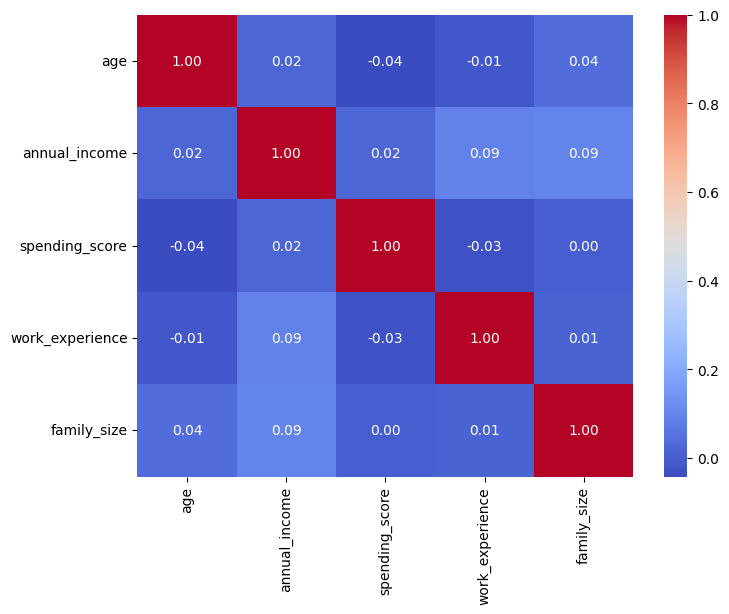

In [ ]:
#Heatmap shows no strong linear relationship between any single feature and spending score: Regression is highly unlikely to be a suitable approach.
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

In [ ]:
#Spendig score is almost same for both gender
df.groupby("gender")["spending_score"].mean()

gender
Female    50.974705
Male      50.944717
Name: spending_score, dtype: float64

In [ ]:
#Profession has minor influence on spending score
df.groupby("profession")["spending_score"].mean()

profession
Artist           52.678105
Doctor           51.900621
Engineer         48.966480
Entertainment    52.940171
Executive        49.901961
Healthcare       50.516224
Homemaker        46.383333
Lawyer           48.859155
Marketing        48.717647
Name: spending_score, dtype: float64

In [ ]:
#No linear trend between income group and spending score.
df["income_group"] = pd.qcut(df["annual_income"], 4)
df.groupby("income_group")["spending_score"].mean()

income_group
(-0.001, 74572.0]        50.188
(74572.0, 110045.0]      49.418
(110045.0, 149092.75]    53.476
(149092.75, 189974.0]    50.768
Name: spending_score, dtype: float64

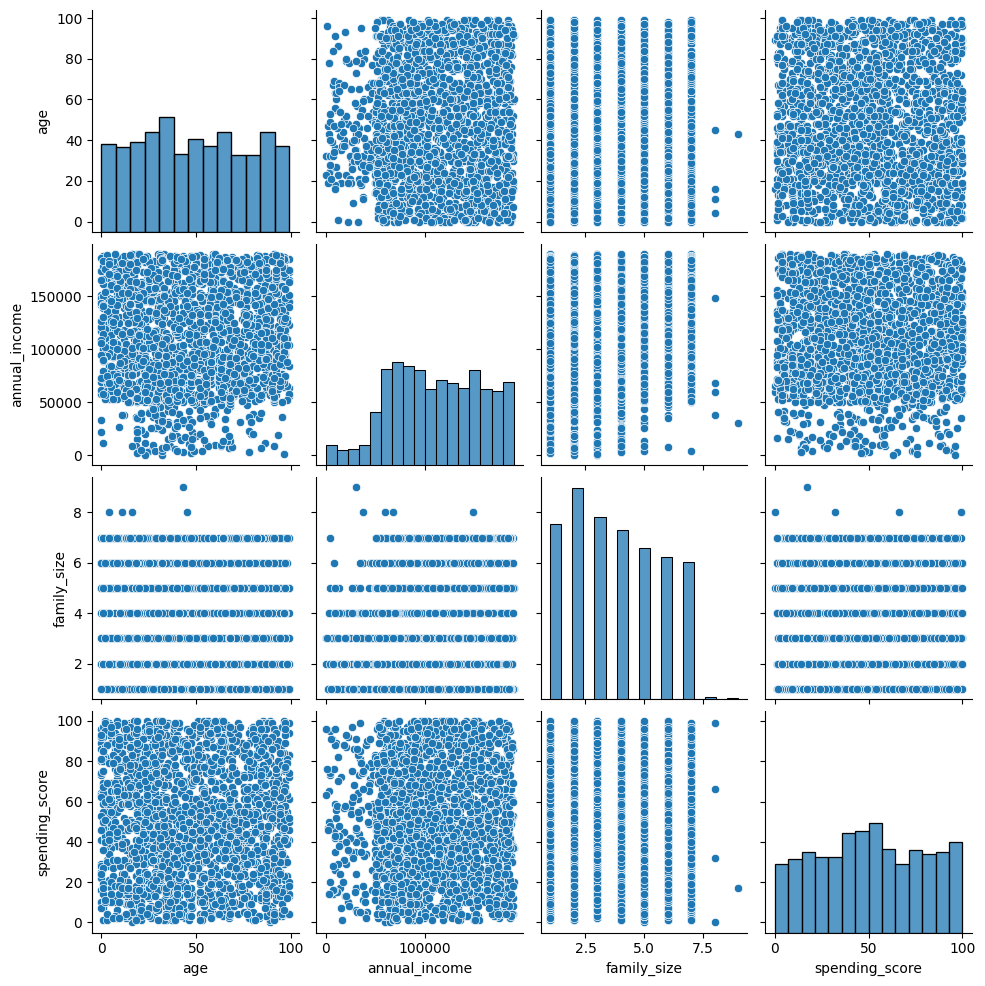

In [ ]:
#Create a pairplot for additional visualization.
#annual income vs spending, age vs spending are random.  No relationship between family size and spending.
#Overall no linear or non-linear pattern.  
sns.pairplot(df[["age", "annual_income", "family_size", "spending_score"]])
plt.show()

###In summary, the above analysis suggests that the spending score is not derived from any of the input features.  May have been assigned randomly or based on a different dataset.